# Age at first marriage

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd

from nsfg.paths import raw, interim, FIGURES
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter

from nsfg.utils import decorate
from nsfg.utils import value_counts
from nsfg.utils import resample_by_cycle
from nsfg.utils import round_into_bins
from nsfg.utils import remove_spines

from empiricaldist import Pmf, Cdf

random_seed = 1

<IPython.core.display.Javascript object>

In [4]:
# Make the figures smaller to save some screen real estate.
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [5, 3.7]

<IPython.core.display.Javascript object>

In [5]:
from nsfg.utils import set_palette, resample_by_cycle

<IPython.core.display.Javascript object>

## Age at first marriage, female respondents

Load the data cleaned in `clean_nsfg.ipynb` and run the analysis with `lifelines`

In [6]:
%time resp = pd.read_parquet(interim("FemMarriageData.parquet"))
resp.shape

CPU times: user 104 ms, sys: 227 ms, total: 332 ms
Wall time: 59.9 ms


(75769, 53)

<IPython.core.display.Javascript object>

In [7]:
evrmarry = resp["evrmarry"]
value_counts(evrmarry)

,counts
values,
False,36608
True,39161


<IPython.core.display.Javascript object>

In [8]:
for name, group in resp.groupby("birth_index"):
    missing = group["evrmarry"] & group["agemarry"].isna()
    print(name, missing.sum())

30 0
40 9
50 18
60 33
70 41
80 20
90 2
100 1


<IPython.core.display.Javascript object>

In [9]:
sample = resample_by_cycle(resp)

<IPython.core.display.Javascript object>

In [10]:
value_counts(sample["birth_index"])

,counts
values,
30,395
40,4002
50,10333
60,15777
70,18094
80,15392
90,9636
100,2140


<IPython.core.display.Javascript object>

In [11]:
def drop_missing(df):
    # find people who are married but have no agemarry
    missing = df["evrmarry"] & df["agemarry"].isna()
    return df[~missing]

<IPython.core.display.Javascript object>

In [12]:
def fill_missing(df):
    for cohort in range(30, 110, 10):
        # find people in this cohort who are married but have no agemarry
        missing = (df["birth_index"] == cohort) & df["evrmarry"] & df["agemarry"].isna()
        n = missing.sum()
        if n == 0:
            continue

        # find people in this cohort who have been married once
        donors = (df["birth_index"] == cohort) & df["evrmarry"] & df["agemarry"].notna()

        # select their ages when married
        agemarry = df.loc[donors, "agemarry"]
        low, high = np.percentile(agemarry, [1, 99])
        index = agemarry.between(low, high)

        # fill missing data with a random sample
        sample = np.random.choice(agemarry[index], size=n, replace=True)
        df.loc[missing, "agemarry"] = sample

<IPython.core.display.Javascript object>

In [13]:
# fill_missing(sample)
sample = drop_missing(sample)

missing = sample["evrmarry"] & sample["agemarry"].isna()
missing.sum()

0

<IPython.core.display.Javascript object>

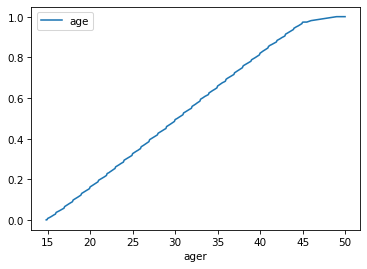

<IPython.core.display.Javascript object>

In [14]:
cdf = Cdf.from_seq(sample["ager"], name="age")
cdf.plot()
decorate()

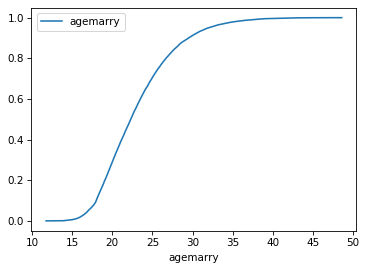

<IPython.core.display.Javascript object>

In [15]:
cdf = Cdf.from_seq(sample["agemarry"], name="agemarry")
cdf.plot()
decorate()

In [16]:
from nsfg.utils import make_kmf_map

<IPython.core.display.Javascript object>

In [17]:
evrmarry = sample["evrmarry"]
sample["observed"] = evrmarry
sample.loc[evrmarry, "duration"] = sample["agemarry"]
sample.loc[~evrmarry, "duration"] = sample["ager"]

<IPython.core.display.Javascript object>

In [18]:
grouped = sample.groupby("birth_index")
nsfg_map = make_kmf_map(grouped)

<IPython.core.display.Javascript object>

In [19]:
from nsfg.utils import add_text

<IPython.core.display.Javascript object>

In [20]:
def make_title(title, subtitle, pad=30):
    plt.title(title, loc="left", pad=pad)
    add_text(0, 1.085, subtitle)
    add_text(0, 1.015, "Analysis: allendowney.com/blog")

<IPython.core.display.Javascript object>

In [21]:
def decorate_plot(subtitle="", **options):
    decorate(
        xlabel="Age",
        ylabel="Percent",
        xlim=[13, 55],
        **options,
    )
    title = "Percent ever married"
    make_title(title, subtitle)

<IPython.core.display.Javascript object>

In [22]:
def plot_kmf_map(ax, kmf_map, cohorts, **options):
    """ """
    palette = set_palette("nipy_spectral", len(cohorts), reverse=True)
    for cohort in cohorts:
        series = kmf_map[cohort]
        label = f"{cohort+1900}s"
        series.plot(ax=ax, label=label, **options)
        label = ""

<IPython.core.display.Javascript object>

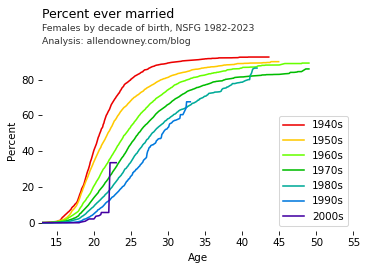

<IPython.core.display.Javascript object>

In [23]:
cohorts = range(40, 110, 10)

fig, ax = plt.subplots()
plot_kmf_map(ax, nsfg_map, cohorts)
decorate_plot(subtitle="Females by decade of birth, NSFG 1982-2023")
remove_spines()
plt.tight_layout()

In [24]:
def make_kmf_series(resp, iters=21):
    kmf_series = {}

    for i in range(iters):
        sample = resample_by_cycle(resp)
        sample = drop_missing(sample)
        evrmarry = sample["evrmarry"]
        sample["observed"] = evrmarry
        sample.loc[evrmarry, "duration"] = sample["agemarry"]
        sample.loc[~evrmarry, "duration"] = sample["ager"]
        grouped = sample.groupby("birth_index")
        kmf_map = make_kmf_map(grouped)
        for cohort in kmf_map:
            kmf_series.setdefault(cohort, []).append(kmf_map[cohort])

    return kmf_series

<IPython.core.display.Javascript object>

In [25]:
from nsfg.utils import adjust_legend


def plot_kmf_series(kmf_series, cohorts, subtitle):
    # always make 7 colors, but only use the last n of them
    palette = sns.color_palette("nipy_spectral", 7)
    palette.reverse()
    n = len(cohorts)
    palette = palette[-n:]

    options = dict(alpha=0.1)

    for i, cohort in enumerate(cohorts):
        label = f"{cohort+1900}s"
        series_list = kmf_series[cohort]
        coords = []
        for series in series_list:
            coords.append((series.index[-1], series.iloc[-1]))
            series.plot(label=label, color=palette[i], **options)
            # only label the first line
            label = ""

    decorate_plot(subtitle, loc="lower right")
    adjust_legend(alpha=1, lw=2)
    remove_spines()
    plt.tight_layout()

<IPython.core.display.Javascript object>

In [26]:
kmf_series = make_kmf_series(resp)

<IPython.core.display.Javascript object>

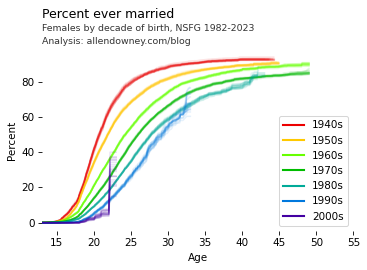

<IPython.core.display.Javascript object>

In [27]:
plot_kmf_series(
    kmf_series, cohorts, subtitle="Females by decade of birth, NSFG 1982-2023"
)
plt.savefig(FIGURES / "marriage_female23.png", dpi=300)

## Age at first marriage, male respondents

Load the data cleaned in `clean_nsfg.ipynb` and run the analysis with `lifelines`

In [28]:
%time resp2 = pd.read_parquet(interim("MaleMarriageData.parquet"))
resp.shape

CPU times: user 57.5 ms, sys: 25.9 ms, total: 83.4 ms
Wall time: 13.5 ms


(75769, 53)

<IPython.core.display.Javascript object>

In [29]:
evrmarry = resp2["evrmarry"]
value_counts(evrmarry)

,counts
values,
False,24634
True,14135


<IPython.core.display.Javascript object>

In [30]:
for name, group in resp2.groupby("birth_index"):
    missing = group["evrmarry"] & group["agemarry"].isna()
    print(name, missing.sum())

50 0
60 0
70 1
80 1
90 1
100 0


<IPython.core.display.Javascript object>

In [31]:
sample = resample_by_cycle(resp2)

<IPython.core.display.Javascript object>

In [32]:
value_counts(sample["birth_index"])

,counts
values,
50,398
60,5026
70,11162
80,12176
90,8182
100,1825


<IPython.core.display.Javascript object>

In [33]:
sample = drop_missing(sample)

missing = sample["evrmarry"] & sample["agemarry"].isna()
missing.sum()

0

<IPython.core.display.Javascript object>

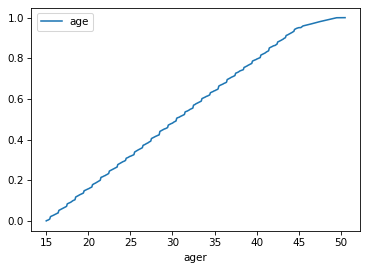

<IPython.core.display.Javascript object>

In [34]:
cdf = Cdf.from_seq(sample["ager"], name="age")
cdf.plot()
decorate()

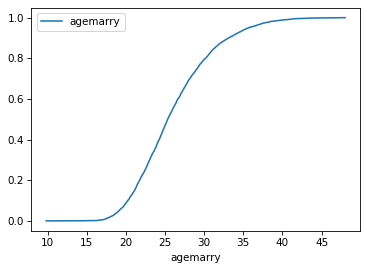

<IPython.core.display.Javascript object>

In [35]:
cdf = Cdf.from_seq(sample["agemarry"], name="agemarry")
cdf.plot()
decorate()

In [36]:
evrmarry = sample["evrmarry"]
sample["observed"] = evrmarry
sample.loc[evrmarry, "duration"] = sample["agemarry"]
sample.loc[~evrmarry, "duration"] = sample["ager"]

<IPython.core.display.Javascript object>

In [37]:
grouped = sample.groupby("birth_index")
nsfg_map = make_kmf_map(grouped)

<IPython.core.display.Javascript object>

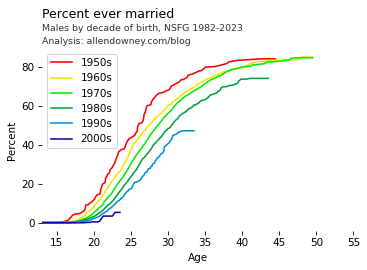

<IPython.core.display.Javascript object>

In [38]:
cohorts = range(50, 110, 10)

fig, ax = plt.subplots()
plot_kmf_map(ax, nsfg_map, cohorts)

decorate_plot(subtitle="Males by decade of birth, NSFG 1982-2023")
remove_spines()
plt.tight_layout()

In [39]:
kmf_series = make_kmf_series(resp2)

<IPython.core.display.Javascript object>

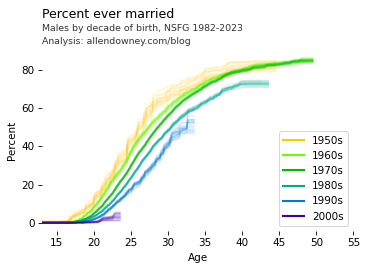

<IPython.core.display.Javascript object>

In [40]:
plot_kmf_series(
    kmf_series, cohorts, subtitle="Males by decade of birth, NSFG 1982-2023"
)
plt.savefig(FIGURES / "marriage_male23.png", dpi=300)